In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ICIWstyle")

In [26]:
n_dot = np.load("FBA-E-18032025_300ml-min_Analytik_MS_composition.npy")
timestamps = np.load("FBA-E-18032025_300ml-min_Analytik_MS_times.npy")

The switching times are ordered in reverse (ie. the index i) is the time at which the i-th-to last switch happened.

In [27]:
switching_periods = np.array(
    [
        5 * 60 + 0.03,
        5 * 60 + 0.27,
        5 * 60 + 0.27,
        5 * 60 + 0.28,
        5 * 60 + 0.18,
        5 * 60 + 0.26,
        5 * 60 + 0.33,
        5 * 60 + 0.27,
        5 * 60 + 0.18,
        5 * 60 + 0.05,
    ]
)
switching_times = np.flip(np.cumsum(-switching_periods))
switching_times = np.append(switching_times, 0) - 1
print(switching_times)

[-3.00312e+03 -2.70307e+03 -2.40289e+03 -2.10262e+03 -1.80229e+03
 -1.50203e+03 -1.20185e+03 -9.01570e+02 -6.01300e+02 -3.01030e+02
 -1.00000e+00]


In [28]:
intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
intervals

[(-3003.12, -2703.0699999999997),
 (-2703.0699999999997, -2402.89),
 (-2402.89, -2102.62),
 (-2102.62, -1802.29),
 (-1802.29, -1502.03),
 (-1502.03, -1201.85),
 (-1201.85, -901.5699999999999),
 (-901.5699999999999, -601.3),
 (-601.3, -301.03),
 (-301.03, -1.0)]

In [ ]:
timestamps = timestamps - timestamps[-1]
time_delta = timestamps.astype("float")


print(time_delta[0] / timestamps.size)
np.savez(
    "FBA-E-18032025_300ml-min_Analytik_MS.npz", n_dot=n_dot.T, time_delta=time_delta
)

t_range = (time_delta.min(), time_delta.max())

-0.2835315427400468


In [30]:
import scipy
import scipy.interpolate

print(time_delta.shape)
print(n_dot.shape)

interp_H2 = scipy.interpolate.interp1d(time_delta, n_dot[:, 0], kind="linear")
interp_Ar = scipy.interpolate.interp1d(time_delta, n_dot[:, 1], kind="linear")

interp_H2(-90)

(13664,)
(13664, 3)


array(3.45318079e-06)

In [31]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot.T,
    kind="linear",
    fill_value="extrapolate",
)

In [32]:
t = np.linspace(*t_range, 1000)
n_dot_interp = interp(t)

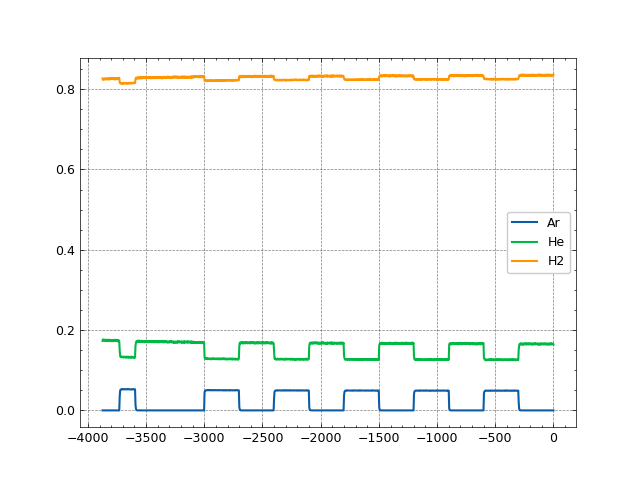

In [33]:
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
plt.plot(t, n_dot_interp[2], label="H2")
plt.legend()

(1, 3, 300)
(1, 3, 300)
(1, 3, 300)
(1, 3, 300)
(1, 3, 300)
(1, 3, 300)
(1, 3, 300)
(1, 3, 300)
(1, 3, 300)
(1, 3, 300)
(10, 3, 300)


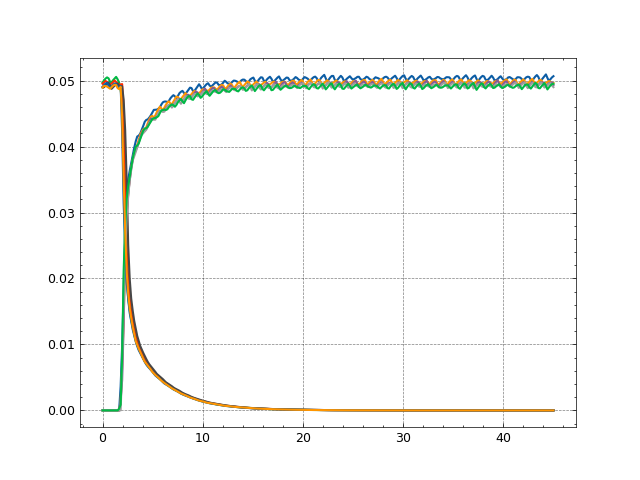

In [36]:
del n_dots
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 45, 300)

    n_dot_interp = interp(t)
    print(n_dot_interp[None, :, :].shape)

    plt.plot(t - interval[0], n_dot_interp[[0]].T)
    try:
        n_dots = np.concatenate((n_dots, n_dot_interp[None, :, :]), axis=0)
    except NameError:
        n_dots = n_dot_interp[None, :, :]
print(n_dots.shape)

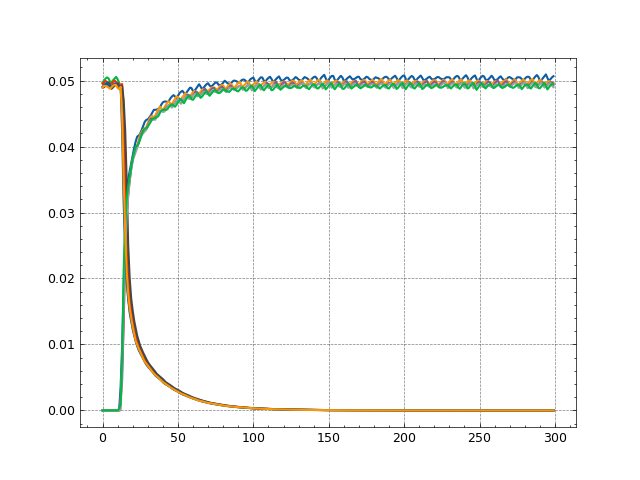

In [35]:
plt.plot(n_dots[:, 0, :].T)